Implement the actual proposed Query-Gated UVD model

Does the actual proposed query-gated UVD method work?

Can query-adaptive object-relative geometry improve open-vocabulary part segmentation, particularly for unseen parent-object categories?

# 09 — Query-Gated Object-Relative UVD Geometry

## Goal

This notebook implements the main proposed method of the project:

**Query-gated object-relative geometry for text-conditioned part segmentation.**

Previous experiments showed whether parent-object masks and explicit
object-relative coordinates can improve segmentation.

Here we introduce three geometric maps:

- **U** — normalized horizontal position inside the parent object
- **V** — normalized vertical position inside the parent object
- **D** — normalized distance from the parent-object boundary

Unlike fixed UVD geometry, the proposed model uses the CLIP text
embedding of the requested part to predict three geometry weights:

\[
\alpha_U,\alpha_V,\alpha_D
\]

These weights determine how strongly each geometric cue contributes
to the segmentation prediction.

The experiment compares:

1. Object-mask baseline
2. Fixed UV geometry
3. Fixed UVD geometry
4. Query-gated UVD geometry

The main question is:

> Does adapting object-relative geometry to the part query improve
> text-conditioned part segmentation, particularly for unseen
> parent-object categories?

In [2]:
from pathlib import Path
import sys
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

from scipy.ndimage import distance_transform_edt

import open_clip

In [3]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT = PROJECT_ROOT.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print(
    "Project root:",
    PROJECT_ROOT,
)

Project root: /run/media/dinely-shanuka/New Volume/UTN/Semester 2/Computer Vision/Computer_Vision_Final_Project/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation


Import dataset

In [4]:
from datasets import PascalPart116Dataset

print(
    "PascalPart116Dataset imported successfully."
)

PascalPart116Dataset imported successfully.


Configuration

Use the same settings as notebooks 03 and 04 so the comparison stays fair.

In [5]:
SEED = 42

IMAGE_SIZE = 224

TRAIN_BATCH_SIZE = 16
VAL_BATCH_SIZE = 16

NUM_WORKERS = 4

EPOCHS = 20

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

VISUAL_DIM = 128
TEXT_DIM = 32

GATE_HIDDEN_DIM = 64

MASK_THRESHOLD = 0.5

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

USE_AMP = torch.cuda.is_available()

OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "experiments"
    / "query_gated_uvd"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

print("Device:", DEVICE)
print("AMP:", USE_AMP)
print("Output:", OUTPUT_ROOT)

Device: cpu
AMP: False
Output: /run/media/dinely-shanuka/New Volume/UTN/Semester 2/Computer Vision/Computer_Vision_Final_Project/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/query_gated_uvd


Seed

In [6]:
def seed_everything(
    seed=42,
):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            seed
        )


seed_everything(SEED)

print(
    "Seed:",
    SEED,
)

Seed: 42


Check your dataset splits

In [7]:
raw_train_dataset = PascalPart116Dataset(
    split="train_seen"
)

raw_val_dataset = PascalPart116Dataset(
    split="validation_seen"
)

raw_test_seen_dataset = PascalPart116Dataset(
    split="test_seen"
)

raw_test_unseen_dataset = PascalPart116Dataset(
    split="test_unseen"
)

print(
    "Train:",
    len(raw_train_dataset),
)

print(
    "Validation:",
    len(raw_val_dataset),
)

print(
    "Test seen:",
    len(raw_test_seen_dataset),
)

print(
    "Test unseen:",
    len(raw_test_unseen_dataset),
)

Train: 32698
Validation: 3708
Test seen: 3371
Test unseen: 1586


ImageNet normalization

This is copied from your existing experiment so DINO receives the same preprocessing.

In [8]:
IMAGENET_MEAN = torch.tensor(
    [
        0.485,
        0.456,
        0.406,
    ],
    dtype=torch.float32,
).view(
    3,
    1,
    1,
)

IMAGENET_STD = torch.tensor(
    [
        0.229,
        0.224,
        0.225,
    ],
    dtype=torch.float32,
).view(
    3,
    1,
    1,
)

Resize information

In [9]:
def get_resize_info(
    height,
    width,
    target_size=224,
):

    scale = min(
        target_size / height,
        target_size / width,
    )

    new_h = max(
        1,
        round(
            height * scale
        ),
    )

    new_w = max(
        1,
        round(
            width * scale
        ),
    )

    pad_h = (
        target_size
        - new_h
    )

    pad_w = (
        target_size
        - new_w
    )

    top = (
        pad_h // 2
    )

    bottom = (
        pad_h - top
    )

    left = (
        pad_w // 2
    )

    right = (
        pad_w - left
    )

    return {
        "new_h": new_h,
        "new_w": new_w,
        "top": top,
        "bottom": bottom,
        "left": left,
        "right": right,
        "scale": scale,
    }

Image preprocessing

In [10]:
def preprocess_image(
    image,
    target_size=224,
):

    image = (
        image.float()
        / 255.0
    )

    _, h, w = (
        image.shape
    )

    info = get_resize_info(
        h,
        w,
        target_size,
    )

    resized = TF.resize(
        image,
        [
            info["new_h"],
            info["new_w"],
        ],
        interpolation=(
            InterpolationMode.BILINEAR
        ),
        antialias=True,
    )

    display_image = F.pad(
        resized,
        (
            info["left"],
            info["right"],
            info["top"],
            info["bottom"],
        ),
        value=0.0,
    )

    normalized = (
        resized
        - IMAGENET_MEAN
    ) / IMAGENET_STD

    model_image = F.pad(
        normalized,
        (
            info["left"],
            info["right"],
            info["top"],
            info["bottom"],
        ),
        value=0.0,
    )

    return (
        display_image,
        model_image,
        info,
    )

Mask preprocessing

In [11]:
def preprocess_mask(
    mask,
    resize_info,
    preserve_positive=False,
):

    if mask.ndim == 2:
        mask = (
            mask.unsqueeze(0)
        )

    mask = (
        mask.float()
    )

    resized = TF.resize(
        mask,
        [
            resize_info["new_h"],
            resize_info["new_w"],
        ],
        interpolation=(
            InterpolationMode.NEAREST
        ),
    )

    if (
        preserve_positive
        and mask.sum() > 0
        and resized.sum() == 0
    ):

        resized = F.interpolate(
            mask.unsqueeze(0),
            size=(
                resize_info["new_h"],
                resize_info["new_w"],
            ),
            mode="area",
        ).squeeze(0)

        resized = (
            resized > 0
        ).float()

    padded = F.pad(
        resized,
        (
            resize_info["left"],
            resize_info["right"],
            resize_info["top"],
            resize_info["bottom"],
        ),
        value=0.0,
    )

    return (
        padded > 0.5
    )

Create relative U and V

This is the same definition as Notebook 04.

In [12]:
def create_relative_uv(
    object_mask,
):

    if object_mask.ndim == 3:
        mask = (
            object_mask.squeeze(0)
        )
    else:
        mask = (
            object_mask
        )

    mask = (
        mask.bool()
    )

    h, w = (
        mask.shape
    )

    u_map = torch.zeros(
        (h, w),
        dtype=torch.float32,
    )

    v_map = torch.zeros(
        (h, w),
        dtype=torch.float32,
    )

    ys, xs = torch.where(
        mask
    )

    if len(xs) == 0:

        return (
            u_map.unsqueeze(0),
            v_map.unsqueeze(0),
        )

    x_min = (
        xs.min()
    )

    x_max = (
        xs.max()
    )

    y_min = (
        ys.min()
    )

    y_max = (
        ys.max()
    )

    x_denom = max(
        int(
            x_max
            - x_min
        ),
        1,
    )

    y_denom = max(
        int(
            y_max
            - y_min
        ),
        1,
    )

    u_values = (
        xs.float()
        - x_min.float()
    ) / x_denom

    v_values = (
        ys.float()
        - y_min.float()
    ) / y_denom

    u_map[
        ys,
        xs,
    ] = (
        u_values
    )

    v_map[
        ys,
        xs,
    ] = (
        v_values
    )

    return (
        u_map.unsqueeze(0),
        v_map.unsqueeze(0),
    )

Distance-to-boundary map D

This is the first new component.

In [13]:
def create_boundary_distance(
    object_mask,
):

    if object_mask.ndim == 3:
        mask = (
            object_mask
            .squeeze(0)
        )
    else:
        mask = (
            object_mask
        )

    mask = (
        mask.bool()
    )

    h, w = (
        mask.shape
    )

    d_map = torch.zeros(
        (h, w),
        dtype=torch.float32,
    )

    if not mask.any():

        return (
            d_map.unsqueeze(0)
        )

    mask_np = (
        mask.cpu()
        .numpy()
        .astype(
            np.uint8
        )
    )

    distance = (
        distance_transform_edt(
            mask_np
        )
    )

    max_distance = (
        distance.max()
    )

    if max_distance > 0:

        distance = (
            distance
            / max_distance
        )

    d_map = torch.from_numpy(
        distance
    ).float()

    d_map = (
        d_map
        * mask.float()
    )

    return (
        d_map.unsqueeze(0)
    )

Test UVD

In [14]:
raw_sample = (
    raw_train_dataset[0]
)

(
    display_image,
    model_image,
    resize_info,
) = preprocess_image(
    raw_sample["image"],
    IMAGE_SIZE,
)

object_mask = preprocess_mask(
    raw_sample[
        "object_mask"
    ],
    resize_info,
    preserve_positive=True,
)

part_mask = preprocess_mask(
    raw_sample[
        "part_mask"
    ],
    resize_info,
    preserve_positive=True,
)

relative_u, relative_v = (
    create_relative_uv(
        object_mask
    )
)

boundary_d = (
    create_boundary_distance(
        object_mask
    )
)

print(
    "Object:",
    raw_sample[
        "object_name"
    ],
)

print(
    "Part:",
    raw_sample[
        "part_name"
    ],
)

print()

print(
    "U:",
    relative_u.shape,
    relative_u.min().item(),
    relative_u.max().item(),
)

print(
    "V:",
    relative_v.shape,
    relative_v.min().item(),
    relative_v.max().item(),
)

print(
    "D:",
    boundary_d.shape,
    boundary_d.min().item(),
    boundary_d.max().item(),
)

Object: tvmonitor
Part: screen

U: torch.Size([1, 224, 224]) 0.0 1.0
V: torch.Size([1, 224, 224]) 0.0 1.0
D: torch.Size([1, 224, 224]) 0.0 1.0


Visualize UVD

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].


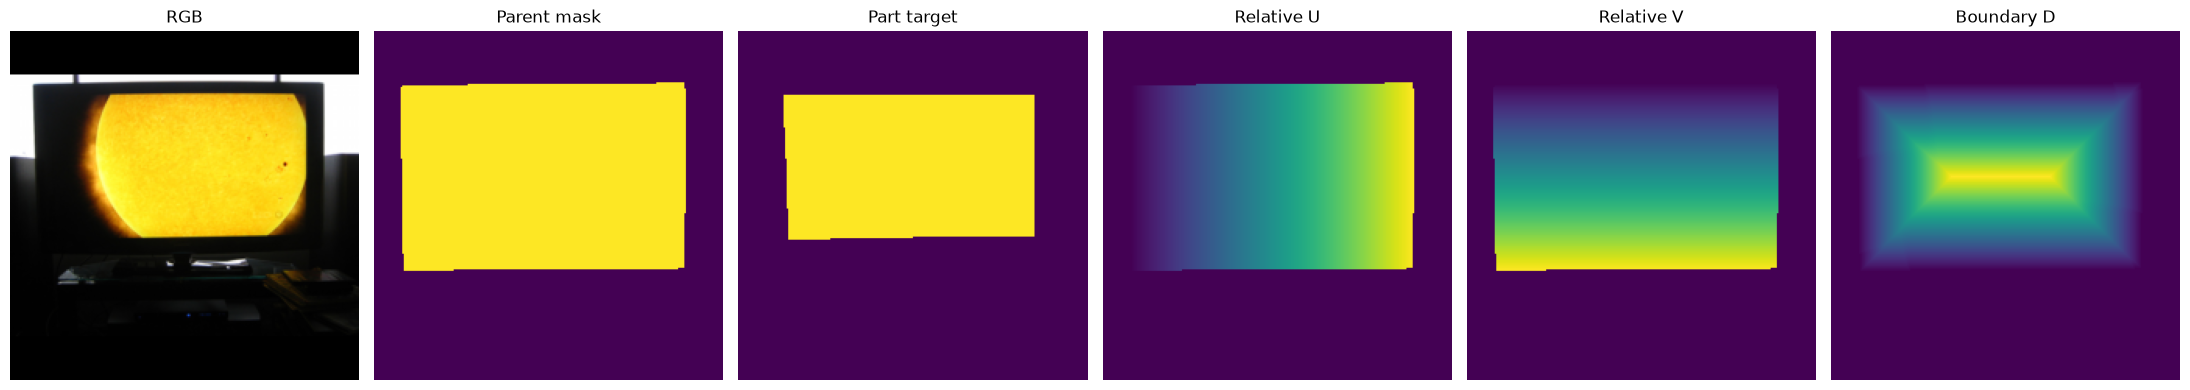

In [15]:
fig, axes = plt.subplots(
    1,
    6,
    figsize=(22, 4),
)

axes[0].imshow(
    display_image
    .permute(
        1,
        2,
        0,
    )
)

axes[0].set_title(
    "RGB"
)

axes[1].imshow(
    object_mask.squeeze()
)

axes[1].set_title(
    "Parent mask"
)

axes[2].imshow(
    part_mask.squeeze()
)

axes[2].set_title(
    "Part target"
)

axes[3].imshow(
    relative_u.squeeze(),
    vmin=0,
    vmax=1,
)

axes[3].set_title(
    "Relative U"
)

axes[4].imshow(
    relative_v.squeeze(),
    vmin=0,
    vmax=1,
)

axes[4].set_title(
    "Relative V"
)

axes[5].imshow(
    boundary_d.squeeze(),
    vmin=0,
    vmax=1,
)

axes[5].set_title(
    "Boundary D"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

UVD dataset

In [16]:
class UVDDataset(Dataset):

    def __init__(
        self,
        split,
        image_size=224,
    ):

        self.base_dataset = (
            PascalPart116Dataset(
                split=split
            )
        )

        self.image_size = (
            image_size
        )

    def __len__(
        self,
    ):

        return len(
            self.base_dataset
        )

    def __getitem__(
        self,
        index,
    ):

        sample = (
            self.base_dataset[
                index
            ]
        )

        (
            display_image,
            image,
            resize_info,
        ) = preprocess_image(
            sample["image"],
            self.image_size,
        )

        object_mask = (
            preprocess_mask(
                sample[
                    "object_mask"
                ],
                resize_info,
                preserve_positive=True,
            )
        )

        part_mask = (
            preprocess_mask(
                sample[
                    "part_mask"
                ],
                resize_info,
                preserve_positive=True,
            )
        )

        overlap = (
            object_mask
            & part_mask
        )

        if (
            part_mask.any()
            and not overlap.any()
        ):

            object_mask = (
                object_mask
                | part_mask
            )

        part_mask = (
            part_mask
            & object_mask
        )

        (
            relative_u,
            relative_v,
        ) = create_relative_uv(
            object_mask
        )

        boundary_d = (
            create_boundary_distance(
                object_mask
            )
        )

        return {

            "sample_id":
                sample[
                    "sample_id"
                ],

            "image_id":
                sample[
                    "image_id"
                ],

            "image":
                image,

            "display_image":
                display_image,

            "object_mask":
                object_mask.float(),

            "part_mask":
                part_mask.float(),

            "relative_u":
                relative_u,

            "relative_v":
                relative_v,

            "boundary_d":
                boundary_d,

            "query":
                sample[
                    "query"
                ],

            "object_name":
                sample[
                    "object_name"
                ],

            "part_name":
                sample[
                    "part_name"
                ],

            "evaluation_split":
                sample[
                    "evaluation_split"
                ],
        }

Create datasets

In [17]:
train_dataset = UVDDataset(
    split="train_seen",
    image_size=IMAGE_SIZE,
)

val_dataset = UVDDataset(
    split="validation_seen",
    image_size=IMAGE_SIZE,
)

test_seen_dataset = UVDDataset(
    split="test_seen",
    image_size=IMAGE_SIZE,
)

test_unseen_dataset = UVDDataset(
    split="test_unseen",
    image_size=IMAGE_SIZE,
)

print(
    "Train:",
    len(train_dataset),
)

print(
    "Validation:",
    len(val_dataset),
)

print(
    "Seen:",
    len(test_seen_dataset),
)

print(
    "Unseen:",
    len(test_unseen_dataset),
)

Train: 32698
Validation: 3708
Seen: 3371
Unseen: 1586


Inspect one sample

In [18]:
sample = (
    train_dataset[0]
)

for key, value in (
    sample.items()
):

    if torch.is_tensor(
        value
    ):

        print(
            f"{key:20s}",
            tuple(
                value.shape
            ),
            value.dtype,
        )

    else:

        print(
            f"{key:20s}",
            value,
        )

sample_id            train:2008_000002:part_115
image_id             2008_000002
image                (3, 224, 224) torch.float32
display_image        (3, 224, 224) torch.float32
object_mask          (1, 224, 224) torch.float32
part_mask            (1, 224, 224) torch.float32
relative_u           (1, 224, 224) torch.float32
relative_v           (1, 224, 224) torch.float32
boundary_d           (1, 224, 224) torch.float32
query                screen
object_name          tvmonitor
part_name            screen
evaluation_split     seen


Validate samples

In [23]:
def validate_uvd_sample(
    sample,
):

    expected_image_shape = (
        3,
        IMAGE_SIZE,
        IMAGE_SIZE,
    )

    expected_map_shape = (
        1,
        IMAGE_SIZE,
        IMAGE_SIZE,
    )

    assert (
        sample["image"].shape
        == expected_image_shape
    )

    for key in [
        "object_mask",
        "part_mask",
        "relative_u",
        "relative_v",
        "boundary_d",
    ]:

        assert (
            sample[key].shape
            == expected_map_shape
        ), key

    obj = (
        sample[
            "object_mask"
        ] > 0.5
    )

    part = (
        sample[
            "part_mask"
        ] > 0.5
    )

    assert torch.all(
        ~part | obj
    )

    for key in [
        "relative_u",
        "relative_v",
        "boundary_d",
    ]:

        assert (
            sample[key].min()
            >= 0
        )

        assert (
            sample[key].max()
            <= 1
        )

        assert torch.all(
            sample[key][
                ~obj
            ] == 0
        )

    return True


validate_uvd_sample(
    train_dataset[0]
)

print(
    "Sample validation passed."
)

Sample validation passed.


Validate random samples

In [24]:
rng = random.Random(
    SEED
)

indices = rng.sample(
    range(
        len(train_dataset)
    ),
    min(
        200,
        len(train_dataset),
    ),
)

for idx in indices:

    validate_uvd_sample(
        train_dataset[idx]
    )

print(
    f"Validated {len(indices)} "
    "UVD samples successfully."
)

Validated 200 UVD samples successfully.


DataLoaders

In [26]:
NUM_WORKERS = 0
PIN_MEMORY = DEVICE.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_seen_loader = DataLoader(
    test_seen_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_unseen_loader = DataLoader(
    test_unseen_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print("DataLoaders recreated")
print("NUM_WORKERS:", NUM_WORKERS)
print("PIN_MEMORY:", PIN_MEMORY)

DataLoaders recreated
NUM_WORKERS: 0
PIN_MEMORY: False


Check batch

In [27]:
batch = next(iter(train_loader))

for key in [
    "image",
    "object_mask",
    "part_mask",
    "relative_u",
    "relative_v",
    "boundary_d",
]:
    print(f"{key:15s}", batch[key].shape)

image           torch.Size([16, 3, 224, 224])
object_mask     torch.Size([16, 1, 224, 224])
part_mask       torch.Size([16, 1, 224, 224])
relative_u      torch.Size([16, 1, 224, 224])
relative_v      torch.Size([16, 1, 224, 224])
boundary_d      torch.Size([16, 1, 224, 224])


Load frozen DINOv2

In [28]:
dino = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14",
)

dino = dino.to(DEVICE)
dino.eval()

for parameter in dino.parameters():
    parameter.requires_grad = False

print("DINOv2 loaded successfully")
print("Device:", DEVICE)
print(
    "Trainable DINO parameters:",
    sum(
        p.numel()
        for p in dino.parameters()
        if p.requires_grad
    ),
)

Using cache found in /home/dinely-shanuka/.cache/torch/hub/facebookresearch_dinov2_main
/home/dinely-shanuka/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/dinely-shanuka/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/dinely-shanuka/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 loaded successfully
Device: cpu
Trainable DINO parameters: 0


In [29]:
clip_model, _, _ = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai",
)

clip_tokenizer = open_clip.get_tokenizer(
    "ViT-B-32"
)

clip_model = clip_model.to(DEVICE)
clip_model.eval()

for parameter in clip_model.parameters():
    parameter.requires_grad = False

print("CLIP loaded successfully")
print("Device:", DEVICE)
print(
    "Trainable CLIP parameters:",
    sum(
        p.numel()
        for p in clip_model.parameters()
        if p.requires_grad
    ),
)

/run/media/dinely-shanuka/New Volume/UTN/Semester 2/Computer Vision/Computer_Vision_Final_Project/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/.venv/lib/python3.14/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP loaded successfully
Device: cpu
Trainable CLIP parameters: 0


CLIP text embedding cache

This prevents us from repeatedly running CLIP for the same part queries during training.

In [30]:
class TextEmbeddingCache:

    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.cache = {}

    @torch.no_grad()
    def _encode_missing(self, queries):

        missing = sorted({
            q for q in queries
            if q not in self.cache
        })

        if not missing:
            return

        prompts = [
            f"a photo of the {q} of an object"
            for q in missing
        ]

        tokens = self.tokenizer(prompts).to(
            self.device
        )

        embeddings = self.model.encode_text(
            tokens
        )

        embeddings = F.normalize(
            embeddings.float(),
            dim=-1,
        )

        for query, embedding in zip(
            missing,
            embeddings,
        ):
            self.cache[query] = (
                embedding.detach().cpu()
            )

    def __call__(self, queries):

        self._encode_missing(queries)

        embeddings = torch.stack([
            self.cache[q]
            for q in queries
        ])

        return embeddings.to(
            self.device
        )


text_encoder = TextEmbeddingCache(
    clip_model,
    clip_tokenizer,
    DEVICE,
)

print("Text embedding cache created.")

Text embedding cache created.


Define the Query Geometry Gate

This is one of the key components of our proposed method. It converts the 512-dimensional CLIP query embedding into three learned weights:

[αU,αV,αD]

In [31]:
class QueryGeometryGate(nn.Module):

    def __init__(
        self,
        input_dim=512,
        hidden_dim=64,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                input_dim,
                hidden_dim,
            ),
            nn.GELU(),
            nn.Linear(
                hidden_dim,
                3,
            ),
        )

    def forward(
        self,
        text_embeddings,
    ):
        gate_logits = self.network(
            text_embeddings
        )

        weights = F.softmax(
            gate_logits,
            dim=-1,
        )

        return weights


print("QueryGeometryGate defined successfully.")

QueryGeometryGate defined successfully.


Test the Query Geometry Gate

We’ll verify that it produces exactly 3 weights per query and that the weights sum to 1.

In [32]:
example_queries = [
    "head",
    "wheel",
    "screen",
    "wing",
]

example_embeddings = text_encoder(
    example_queries
)

test_gate = QueryGeometryGate(
    input_dim=512,
    hidden_dim=64,
).to(DEVICE)

with torch.no_grad():
    example_weights = test_gate(
        example_embeddings
    )

for query, weights in zip(
    example_queries,
    example_weights,
):
    print(
        query,
        weights.cpu().numpy().round(4),
        "sum =",
        round(
            weights.sum().item(),
            4,
        ),
    )

head [0.3171 0.3643 0.3186] sum = 1.0
wheel [0.3176 0.3638 0.3186] sum = 1.0
screen [0.317  0.3645 0.3185] sum = 1.0
wing [0.3181 0.364  0.3179] sum = 1.0


Define the main UVD segmentation model

This model supports both:

fixed_uvd
query_gated_uvd

In [33]:
class UVDPartSegmenter(nn.Module):

    def __init__(
        self,
        dino_encoder,
        mode,
        visual_dim=128,
        text_dim=32,
        gate_hidden_dim=64,
    ):
        super().__init__()

        assert mode in {
            "fixed_uvd",
            "query_gated_uvd",
        }

        self.mode = mode
        self.dino = dino_encoder

        for parameter in self.dino.parameters():
            parameter.requires_grad = False

        self.visual_projection = nn.Conv2d(
            384,
            visual_dim,
            kernel_size=1,
        )

        self.text_projection = nn.Sequential(
            nn.Linear(
                512,
                64,
            ),
            nn.GELU(),
            nn.Linear(
                64,
                text_dim,
            ),
        )

        if mode == "query_gated_uvd":
            self.geometry_gate = QueryGeometryGate(
                input_dim=512,
                hidden_dim=gate_hidden_dim,
            )
        else:
            self.geometry_gate = None

        fusion_dim = (
            visual_dim
            + text_dim
            + 1   # parent mask
            + 3   # U, V, D
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(
                fusion_dim,
                128,
                kernel_size=3,
                padding=1,
            ),
            nn.GroupNorm(
                8,
                128,
            ),
            nn.GELU(),

            nn.Conv2d(
                128,
                64,
                kernel_size=3,
                padding=1,
            ),
            nn.GroupNorm(
                8,
                64,
            ),
            nn.GELU(),

            nn.Conv2d(
                64,
                32,
                kernel_size=3,
                padding=1,
            ),
            nn.GELU(),

            nn.Conv2d(
                32,
                1,
                kernel_size=1,
            ),
        )

    def train(
        self,
        mode=True,
    ):
        super().train(mode)

        # Keep frozen DINO in eval mode
        self.dino.eval()

        return self

    def extract_dino_features(
        self,
        images,
    ):
        with torch.no_grad():
            output = self.dino.forward_features(
                images
            )

            tokens = output[
                "x_norm_patchtokens"
            ]

        batch_size, num_tokens, channels = (
            tokens.shape
        )

        grid_size = int(
            num_tokens ** 0.5
        )

        features = (
            tokens
            .transpose(
                1,
                2,
            )
            .reshape(
                batch_size,
                channels,
                grid_size,
                grid_size,
            )
        )

        return features

    def forward(
        self,
        images,
        text_embeddings,
        object_mask,
        relative_u,
        relative_v,
        boundary_d,
        return_gate_weights=False,
    ):

        dino_features = (
            self.extract_dino_features(
                images
            )
        )

        visual = self.visual_projection(
            dino_features
        )

        text = self.text_projection(
            text_embeddings
        )

        text_map = (
            text[
                :,
                :,
                None,
                None,
            ]
            .expand(
                -1,
                -1,
                visual.shape[-2],
                visual.shape[-1],
            )
        )

        spatial_size = (
            visual.shape[-2:]
        )

        mask_low = F.interpolate(
            object_mask,
            size=spatial_size,
            mode="nearest",
        )

        u_low = F.interpolate(
            relative_u,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )

        v_low = F.interpolate(
            relative_v,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )

        d_low = F.interpolate(
            boundary_d,
            size=spatial_size,
            mode="bilinear",
            align_corners=False,
        )

        u_low = u_low * mask_low
        v_low = v_low * mask_low
        d_low = d_low * mask_low

        if self.mode == "fixed_uvd":
            gate_weights = torch.ones(
                (
                    images.shape[0],
                    3,
                ),
                device=images.device,
                dtype=visual.dtype,
            )

            weighted_u = u_low
            weighted_v = v_low
            weighted_d = d_low

        else:
            gate_weights = self.geometry_gate(
                text_embeddings.float()
            )

            alpha_u = gate_weights[:, 0].view(
                -1,
                1,
                1,
                1,
            )

            alpha_v = gate_weights[:, 1].view(
                -1,
                1,
                1,
                1,
            )

            alpha_d = gate_weights[:, 2].view(
                -1,
                1,
                1,
                1,
            )

            weighted_u = alpha_u * u_low
            weighted_v = alpha_v * v_low
            weighted_d = alpha_d * d_low

        fused = torch.cat(
            [
                visual,
                text_map,
                mask_low,
                weighted_u,
                weighted_v,
                weighted_d,
            ],
            dim=1,
        )

        logits_low = self.decoder(
            fused
        )

        logits = F.interpolate(
            logits_low,
            size=images.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        if return_gate_weights:
            return (
                logits,
                gate_weights,
            )

        return logits


print("UVDPartSegmenter defined successfully.")

UVDPartSegmenter defined successfully.


Compare trainable parameter counts

This checks how much extra capacity the query gate adds.

In [34]:
modes = [
    "fixed_uvd",
    "query_gated_uvd",
]

parameter_counts = {}

for mode in modes:

    model = UVDPartSegmenter(
        dino_encoder=dino,
        mode=mode,
        visual_dim=VISUAL_DIM,
        text_dim=TEXT_DIM,
        gate_hidden_dim=GATE_HIDDEN_DIM,
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    parameter_counts[mode] = trainable

for mode, count in parameter_counts.items():
    print(
        f"{mode:20s}",
        f"{count:,} trainable parameters",
    )

print(
    "\nExtra parameters from query gate:",
    f"{parameter_counts['query_gated_uvd'] - parameter_counts['fixed_uvd']:,}",
)

fixed_uvd            365,921 trainable parameters
query_gated_uvd      398,948 trainable parameters

Extra parameters from query gate: 33,027


Forward-pass test

This checks that both fixed_uvd and query_gated_uvd produce valid segmentation logits with shape: [B, 1, 224, 224]

In [37]:
batch = next(iter(train_loader))

images = batch["image"].to(DEVICE)
object_masks = batch["object_mask"].to(DEVICE)
relative_u = batch["relative_u"].to(DEVICE)
relative_v = batch["relative_v"].to(DEVICE)
boundary_d = batch["boundary_d"].to(DEVICE)

text_embeddings = text_encoder(
    batch["query"]
)

for mode in [
    "fixed_uvd",
    "query_gated_uvd",
]:
    test_model = UVDPartSegmenter(
        dino_encoder=dino,
        mode=mode,
        visual_dim=VISUAL_DIM,
        text_dim=TEXT_DIM,
        gate_hidden_dim=GATE_HIDDEN_DIM,
    ).to(DEVICE)

    with torch.no_grad():
        output = test_model(
            images,
            text_embeddings,
            object_masks,
            relative_u,
            relative_v,
            boundary_d,
        )

    print(
        mode,
        output.shape,
        "finite:",
        torch.isfinite(output).all().item(),
    )

fixed_uvd torch.Size([16, 1, 224, 224]) finite: True
query_gated_uvd torch.Size([16, 1, 224, 224]) finite: True


Define Dice loss

This will be combined with BCE for the segmentation objective.

In [38]:
def dice_loss(
    logits,
    targets,
    eps=1e-6,
):
    probabilities = torch.sigmoid(
        logits
    ).flatten(1)

    targets = targets.flatten(1)

    intersection = (
        probabilities
        * targets
    ).sum(dim=1)

    denominator = (
        probabilities.sum(dim=1)
        + targets.sum(dim=1)
    )

    dice = (
        2 * intersection
        + eps
    ) / (
        denominator
        + eps
    )

    return (
        1 - dice
    ).mean()


print("Dice loss defined successfully.")

Dice loss defined successfully.


Define combined BCE + Dice loss

This matches the loss setup in your proposal: binary cross-entropy + Dice loss.

In [39]:
def segmentation_loss(
    logits,
    targets,
):
    bce = F.binary_cross_entropy_with_logits(
        logits,
        targets,
    )

    dice = dice_loss(
        logits,
        targets,
    )

    total = bce + dice

    return {
        "total": total,
        "bce": bce,
        "dice": dice,
    }


print("Segmentation loss defined successfully.")

Segmentation loss defined successfully.


Define IoU metric

This calculates Intersection over Union (IoU) for each sample, one of our main evaluation metrics.

In [40]:
@torch.no_grad()
def batch_iou(
    logits,
    targets,
    threshold=0.5,
    eps=1e-6,
):
    predictions = (
        torch.sigmoid(logits)
        >= threshold
    )

    targets = (
        targets >= 0.5
    )

    predictions = predictions.flatten(1)
    targets = targets.flatten(1)

    intersection = (
        predictions & targets
    ).sum(dim=1).float()

    union = (
        predictions | targets
    ).sum(dim=1).float()

    iou = (
        intersection + eps
    ) / (
        union + eps
    )

    return iou


print("IoU metric defined successfully.")

IoU metric defined successfully.


Define Dice metric

This is the evaluation version of Dice. Unlike dice_loss, it thresholds the prediction into a binary segmentation mask.

In [41]:
@torch.no_grad()
def batch_dice(
    logits,
    targets,
    threshold=0.5,
    eps=1e-6,
):
    predictions = (
        torch.sigmoid(logits)
        >= threshold
    )

    targets = (
        targets >= 0.5
    )

    predictions = predictions.flatten(1)
    targets = targets.flatten(1)

    intersection = (
        predictions & targets
    ).sum(dim=1).float()

    denominator = (
        predictions.sum(dim=1)
        + targets.sum(dim=1)
    ).float()

    dice = (
        2 * intersection + eps
    ) / (
        denominator + eps
    )

    return dice


print("Dice metric defined successfully.")

Dice metric defined successfully.


Define the training/evaluation epoch

This function will be used for both training and validation.

In [43]:
def run_epoch(
    model,
    loader,
    text_encoder,
    optimizer=None,
    scaler=None,
    threshold=0.5,
    max_batches=None,
):
    training = optimizer is not None

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_iou = 0.0
    total_dice = 0.0
    total_samples = 0

    for batch_index, batch in enumerate(loader):

        if (
            max_batches is not None
            and batch_index >= max_batches
        ):
            break

        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )

        object_mask = batch["object_mask"].to(
            DEVICE,
            non_blocking=True,
        )

        targets = batch["part_mask"].to(
            DEVICE,
            non_blocking=True,
        )

        relative_u = batch["relative_u"].to(
            DEVICE,
            non_blocking=True,
        )

        relative_v = batch["relative_v"].to(
            DEVICE,
            non_blocking=True,
        )

        boundary_d = batch["boundary_d"].to(
            DEVICE,
            non_blocking=True,
        )

        text_embeddings = text_encoder(
            batch["query"]
        )

        batch_size = images.shape[0]

        if training:
            optimizer.zero_grad(
                set_to_none=True
            )

        with torch.set_grad_enabled(training):

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):
                logits = model(
                    images,
                    text_embeddings,
                    object_mask,
                    relative_u,
                    relative_v,
                    boundary_d,
                )

                losses = segmentation_loss(
                    logits,
                    targets,
                )

            if training:

                if scaler is not None and USE_AMP:

                    scaler.scale(
                        losses["total"]
                    ).backward()

                    scaler.unscale_(
                        optimizer
                    )

                    torch.nn.utils.clip_grad_norm_(
                        (
                            p
                            for p in model.parameters()
                            if p.requires_grad
                        ),
                        max_norm=1.0,
                    )

                    scaler.step(
                        optimizer
                    )

                    scaler.update()

                else:

                    losses["total"].backward()

                    torch.nn.utils.clip_grad_norm_(
                        (
                            p
                            for p in model.parameters()
                            if p.requires_grad
                        ),
                        max_norm=1.0,
                    )

                    optimizer.step()

        with torch.no_grad():

            ious = batch_iou(
                logits,
                targets,
                threshold,
            )

            dices = batch_dice(
                logits,
                targets,
                threshold,
            )

        total_loss += (
            losses["total"].item()
            * batch_size
        )

        total_iou += ious.sum().item()
        total_dice += dices.sum().item()

        total_samples += batch_size

    return {
        "loss": total_loss / total_samples,
        "iou": total_iou / total_samples,
        "dice": total_dice / total_samples,
    }


print("GPU-ready run_epoch defined successfully.")
print("Current device:", DEVICE)
print("AMP enabled:", USE_AMP)

GPU-ready run_epoch defined successfully.
Current device: cpu
AMP enabled: False


Define checkpoint save helper

This saves only the trainable components, while DINOv2 stays frozen and does not get duplicated into every checkpoint.

In [44]:
def get_trainable_state(
    model,
):
    state = {
        "visual_projection":
            model.visual_projection.state_dict(),

        "text_projection":
            model.text_projection.state_dict(),

        "decoder":
            model.decoder.state_dict(),
    }

    if model.geometry_gate is not None:
        state["geometry_gate"] = (
            model.geometry_gate.state_dict()
        )

    return state


print("Checkpoint save helper defined successfully.")

Checkpoint save helper defined successfully.


Define checkpoint load helper

This restores the trainable parts later from best.pt or last.pt.

In [45]:
def load_trainable_state(
    model,
    checkpoint,
):
    state = checkpoint["model_state"]

    model.visual_projection.load_state_dict(
        state["visual_projection"]
    )

    model.text_projection.load_state_dict(
        state["text_projection"]
    )

    model.decoder.load_state_dict(
        state["decoder"]
    )

    if model.geometry_gate is not None:
        model.geometry_gate.load_state_dict(
            state["geometry_gate"]
        )

    return model


print("Checkpoint load helper defined successfully.")

Checkpoint load helper defined successfully.


GPU-aware smoke test

This checks that training works for a couple of batches before you launch the full experiment on GPU.

In [47]:
smoke_model = UVDPartSegmenter(
    dino_encoder=dino,
    mode="query_gated_uvd",
    visual_dim=VISUAL_DIM,
    text_dim=TEXT_DIM,
    gate_hidden_dim=GATE_HIDDEN_DIM,
).to(DEVICE)

smoke_optimizer = torch.optim.AdamW(
    (
        p
        for p in smoke_model.parameters()
        if p.requires_grad
    ),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

smoke_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)

smoke_metrics = run_epoch(
    smoke_model,
    train_loader,
    text_encoder,
    optimizer=smoke_optimizer,
    scaler=smoke_scaler,
    threshold=MASK_THRESHOLD,
    max_batches=2,
)

print("Smoke test metrics:")
print(smoke_metrics)

del smoke_model
del smoke_optimizer

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Smoke test metrics:
{'loss': 1.494627594947815, 'iou': 0.008956034460492646, 'dice': 0.016424854078717743}


Define the full experiment training function

This will train either fixed_uvd or query_gated_uvd, track validation performance, use a learning-rate scheduler, and save best.pt and last.pt.

In [48]:
def train_uvd_experiment(
    mode,
    epochs=EPOCHS,
):
    seed_everything(SEED)

    experiment_dir = OUTPUT_ROOT / mode
    experiment_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    model = UVDPartSegmenter(
        dino_encoder=dino,
        mode=mode,
        visual_dim=VISUAL_DIM,
        text_dim=TEXT_DIM,
        gate_hidden_dim=GATE_HIDDEN_DIM,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        (
            p
            for p in model.parameters()
            if p.requires_grad
        ),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
    )

    config = {
        "mode": mode,
        "seed": SEED,
        "image_size": IMAGE_SIZE,
        "epochs": epochs,
        "batch_size": TRAIN_BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "visual_dim": VISUAL_DIM,
        "text_dim": TEXT_DIM,
        "gate_hidden_dim": GATE_HIDDEN_DIM,
        "threshold": MASK_THRESHOLD,
        "dino": "dinov2_vits14",
        "clip": "ViT-B-32/openai",
    }

    with open(
        experiment_dir / "config.json",
        "w",
    ) as f:
        json.dump(
            config,
            f,
            indent=2,
        )

    history = []
    best_val_iou = -1.0

    for epoch in range(
        1,
        epochs + 1,
    ):
        start_time = time.time()

        train_metrics = run_epoch(
            model,
            train_loader,
            text_encoder,
            optimizer=optimizer,
            scaler=scaler,
            threshold=MASK_THRESHOLD,
        )

        val_metrics = run_epoch(
            model,
            val_loader,
            text_encoder,
            optimizer=None,
            scaler=None,
            threshold=MASK_THRESHOLD,
        )

        scheduler.step(
            val_metrics["iou"]
        )

        elapsed = (
            time.time()
            - start_time
        )

        current_lr = (
            optimizer
            .param_groups[0]["lr"]
        )

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_iou": train_metrics["iou"],
            "train_dice": train_metrics["dice"],
            "val_loss": val_metrics["loss"],
            "val_iou": val_metrics["iou"],
            "val_dice": val_metrics["dice"],
            "learning_rate": current_lr,
            "seconds": elapsed,
        }

        history.append(row)

        print(
            f"[{mode}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_metrics['loss']:.4f} | "
            f"train IoU {train_metrics['iou']:.4f} | "
            f"val IoU {val_metrics['iou']:.4f} | "
            f"val Dice {val_metrics['dice']:.4f} | "
            f"lr {current_lr:.2e} | "
            f"{elapsed:.1f}s"
        )

        checkpoint = {
            "epoch": epoch,
            "mode": mode,
            "model_state": get_trainable_state(
                model
            ),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "val_metrics": val_metrics,
            "config": config,
        }

        torch.save(
            checkpoint,
            experiment_dir / "last.pt",
        )

        if (
            val_metrics["iou"]
            > best_val_iou
        ):
            best_val_iou = (
                val_metrics["iou"]
            )

            torch.save(
                checkpoint,
                experiment_dir / "best.pt",
            )

            print(
                f"  -> New best model saved "
                f"(val IoU={best_val_iou:.4f})"
            )

        with open(
            experiment_dir / "history.json",
            "w",
        ) as f:
            json.dump(
                history,
                f,
                indent=2,
            )

    print()
    print(
        f"Training complete: {mode}"
    )
    print(
        f"Best validation IoU: "
        f"{best_val_iou:.4f}"
    )
    print(
        f"Saved to: {experiment_dir}"
    )

    return model, history


print("Full experiment training function defined.")

Full experiment training function defined.


Start training the fixed UVD model

Because you said you’ll train on GPU, run this on the GPU machine/session after confirming: